# Case Study: Brazilian E-commerce Customer Satisfaction Analysis
## Business Question: What drives low customer review scores at Olist and where should the business focus on?

**Author:** Adrian 

**Date:** March 2026

**Goal:** Identify which operational and product factors are most associated with low review scores (1-2 stars)

In [2]:
# Importing Datasets
import pandas as pd
orders = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/olist_orders_dataset.csv")
reviews = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/olist_order_reviews_dataset.csv")
items = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/olist_order_items_dataset.csv")
products = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/olist_products_dataset.csv")
sellers = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/olist_sellers_dataset.csv")
translation = pd.read_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/data/product_category_name_translation.csv")

In [3]:
# Inspect dataframes to compare
dfs = {
    'orders': orders,
    'reviews': reviews,
    'items': items,
    'products': products,
    'sellers': sellers,
}

for name, df in dfs.items():
    print(f'\n{"="*50}')
    print(f'  {name.upper()}')
    print(f'{"="*50}')
    print(f'Shape: {df.shape}')
    print(f'\nHead:')
    display(df.head())
    print(f'\nInfo:')
    df.info()
    print(f'\nUnique values per column:')
    print(df.nunique())


  ORDERS
Shape: (99441, 8)

Head:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Unique values per column:
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB

Unique values per column:
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

  ITEMS
Shape: (112650, 7)

Head:


...


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Unique values per column:
order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

  PRODUCTS
Shape: (32951, 9)

Head:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB

Unique values per column:
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Unique values per column:
seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64


## Info from datasets 

**orders:** 99,441 rows 

**reviews:** 99,224 rows 

**order_items:** 112,650 rows 

**products:** 32,951 rows

**sellers:** 3,095 rows


**order_items** has more rows than **orders** which shows that some orders have multiple items and if we join to order_items, it will increase row count

In [4]:
# Join tables to create one dataset we can analyze
olist_df = orders.copy()
olist_df.shape

(99441, 8)

In [5]:
olist_df = olist_df.merge(reviews, how="left", on="order_id") # join on left since some orders may not have reviews and do not want to drop them
olist_df.shape

(99992, 14)

In [6]:
olist_df = olist_df.merge(items, how= "left", on = "order_id") # dataset is item-level now -> each row is one item in an order
olist_df.shape

(114092, 20)

In [7]:
olist_df = olist_df.merge(products, how="left", on="product_id")
olist_df.shape

(114092, 28)

In [8]:
olist_df = olist_df.merge(sellers, how="left", on="seller_id")
olist_df = olist_df.merge(translation, how ="left", on="product_category_name") # english translation names for categories
olist_df.shape

(114092, 32)

In [9]:
# sanity checks before analysis
olist_df.head()
olist_df.info()
olist_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114092 entries, 0 to 114091
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114092 non-null  object 
 1   customer_id                    114092 non-null  object 
 2   order_status                   114092 non-null  object 
 3   order_purchase_timestamp       114092 non-null  object 
 4   order_approved_at              113930 non-null  object 
 5   order_delivered_carrier_date   112112 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  114092 non-null  object 
 8   review_id                      113131 non-null  object 
 9   review_score                   113131 non-null  float64
 10  review_comment_title           13523 non-null   object 
 11  review_comment_message         48166 non-null   object 
 12  review_creation_date          

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   162
order_delivered_carrier_date       1980
order_delivered_customer_date      3253
order_estimated_delivery_date         0
review_id                           961
review_score                        961
review_comment_title             100569
review_comment_message            65926
review_creation_date                961
review_answer_timestamp             961
order_item_id                       778
product_id                          778
seller_id                           778
shipping_limit_date                 778
price                               778
freight_value                       778
product_category_name              2390
product_name_lenght                2390
product_description_lenght         2390
product_photos_qty                 2390
product_weight_g                    796


In [11]:
olist_df.to_csv("/Users/adrianmar/Desktop/Personal/brazil-ecommerce/olist_master_dataset.csv", index="False")

**Here, I built a final master dataset ready for analysis by joining multiple relational tables and carefully handled grain changes when the dataset moved from order-level data to item-level data.**

**Granularity:** After joining on order_items, one row represents one item in an order.

**Order ID:** is no longer unique because orders can have multiple items so the dataset will show the same order_id multiple times if that order had multiple items. 

**Average Review Score:** biased because orders with more items appear multiple times so we need to fix this moving forward. 

In [12]:
# Convert data columns from strings to datetime
olist_df["order_purchase_timestamp"] = pd.to_datetime(olist_df["order_purchase_timestamp"])
olist_df["order_delivered_customer_date"] = pd.to_datetime(olist_df["order_delivered_customer_date"])
olist_df["order_estimated_delivery_date"] = pd.to_datetime(olist_df["order_estimated_delivery_date"])

In [13]:
# Create delivery time/delay columns
olist_df["delivery_days"] = (olist_df["order_delivered_customer_date"] - olist_df["order_purchase_timestamp"]).dt.days # delivery time
olist_df["delay_days"] = (olist_df["order_delivered_customer_date"] - olist_df["order_estimated_delivery_date"]).dt.days # delay time (+ is late, - is early)
olist_df["is_late"] = olist_df["delay_days"] > 0 # late flag indicator
olist_df["order_value"] = olist_df["price"] + olist_df["freight_value"] # do more expensive orders get better or worse reviews?
olist_df["low_review"] = olist_df["review_score"].isin([1, 2]) # low reviews = 1 or 2 stars, main outcome variable

In [14]:
# Olist sanity check after building our features
olist_df[['delivery_days', 'delay_days', 'is_late', 'order_value', 'low_review']].describe()

,delivery_days,delay_days,order_value
count,110839.000000,110839.000000,113314.000000
mean,12.012414,-12.035809,140.458128
std,9.445470,10.159965,190.362183
min,0.000000,-147.000000,6.080000
25%,6.000000,-17.000000,55.180000
50%,10.000000,-13.000000,92.205000
75%,15.000000,-7.000000,157.790000
max,209.000000,188.000000,6929.310000


In [15]:
olist_df['is_late'].mean()

np.float64(0.06393086281246713)

In [16]:
olist_df['low_review'].mean()

np.float64(0.163999228692634)

**% of late orders:** ~ 6.4%
This means most orders are on time or early, however late deliveries could still have an impact even if they aren't as frequent.

**% of low reviews:** ~ 16.4%
A pretty high percentage which shows that there is a real customer satisfaction problem. 

**Focus Question:** What is causing these low reviews?

**Graphical Models - explain trends or findings in a visual aspect**

In [17]:
# First Check: Late Delivery vs Reviews - Do late deliveries translate to lower review scores?
olist_df.groupby('is_late')['review_score'].mean()
olist_df.groupby('is_late')['low_review'].mean()

is_late
False    0.133289
True     0.613655
Name: low_review, dtype: float64

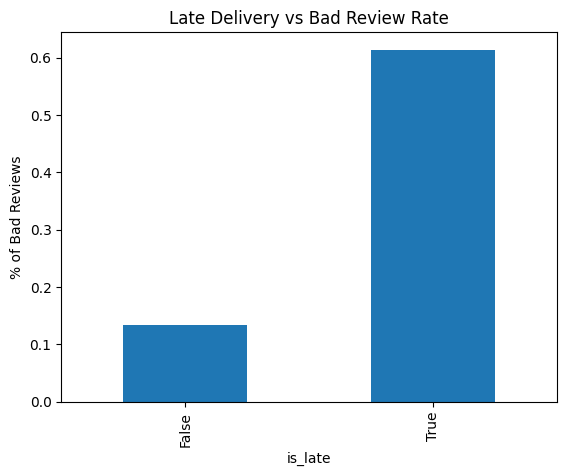

In [18]:
import matplotlib.pyplot as plt
olist_df.groupby('is_late')['low_review'].mean().plot(kind='bar')
plt.title('Late Delivery vs Bad Review Rate')
plt.ylabel('% of Bad Reviews')
plt.show()

Late deliveries significantly increase the likelihood of a low review, with a jump to over 60% of late orders receiving lower ratings compared to just 13% for on-time orders. This suggests that late orders are a primary factor towards customer dissatisfaction, yet other factors could be strong drivers as well. 

In [19]:
# Second Check: Delay Severity - Do unhappy customers tend to experience more delay?
olist_df.groupby('is_late')['delay_days'].mean()

is_late
False   -13.622937
True     10.494927
Name: delay_days, dtype: float64

There is a clear separation in days it takes for an order to arrive, with not late orders typically arriving much earlier and late orders arriving much later. This helps reinforce our idea that delivery timing strongly impacts customer satisfaction.

In [20]:
# Third Check: Worst-performing Categories
olist_df.groupby('product_category_name_english')['review_score'].mean().sort_values().head(10)

product_category_name_english
security_and_services                2.500000
diapers_and_hygiene                  3.256410
office_furniture                     3.493183
home_comfort_2                       3.629630
fashion_male_clothing                3.641221
fixed_telephony                      3.683206
party_supplies                       3.767442
fashio_female_clothing               3.780000
furniture_mattress_and_upholstery    3.815789
audio                                3.825485
Name: review_score, dtype: float64

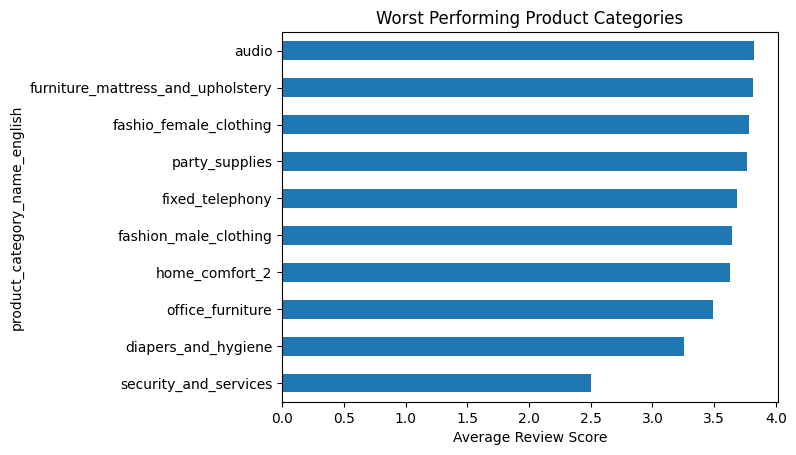

In [21]:
olist_df.groupby('product_category_name_english')['review_score'].mean().sort_values().head(10).plot(kind='barh')
plt.title('Worst Performing Product Categories')
plt.xlabel('Average Review Score')
plt.show()

Certain product categories such as 'security and services' show consistently lower review scores, which could promote the idea that issues with different department categories could be the cause for lower reviews. 

In [22]:
# Fourth Check: Seller Performance - Which sellers/regions are causing the delays?
olist_df.groupby('seller_state')['is_late'].mean().sort_values(ascending = False)

seller_state
AM    0.333333
MA    0.192118
RN    0.071429
SP    0.069377
RJ    0.067425
CE    0.063830
MS    0.060000
DF    0.058824
ES    0.056452
PR    0.051555
SC    0.047444
MG    0.046879
BA    0.043411
MT    0.041379
PE    0.033482
RS    0.031674
PB    0.026316
GO    0.024952
SE    0.000000
AC    0.000000
RO    0.000000
PI    0.000000
PA    0.000000
Name: is_late, dtype: float64

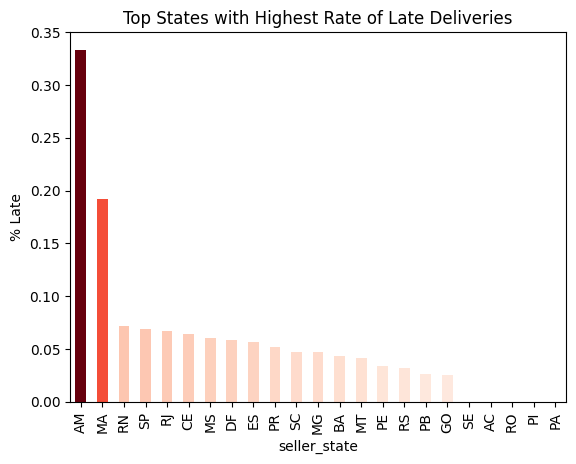

In [23]:

seller_perf = olist_df.groupby('seller_state')['is_late'].mean().sort_values(ascending = False)
seller_perf.plot(kind='bar', color=plt.cm.Reds(seller_perf / seller_perf.max()))
plt.title('Top States with Highest Rate of Late Deliveries')
plt.ylabel('% Late')
plt.show()

Seller performance varies by region, with some states showing a much higher late delivery rate which could be an indicator of inefficiencies in their operations. 

In [24]:
# Fifth Check: Price and Shipping Problems - Is the shipping cost a problem or are unhappy customers paying more?
olist_df.groupby('low_review')['order_value'].mean()

low_review
False    139.395244
True     146.046059
Name: order_value, dtype: float64

In [25]:
olist_df.groupby('low_review')['freight_value'].mean()

low_review
False    19.755565
True     21.156348
Name: freight_value, dtype: float64

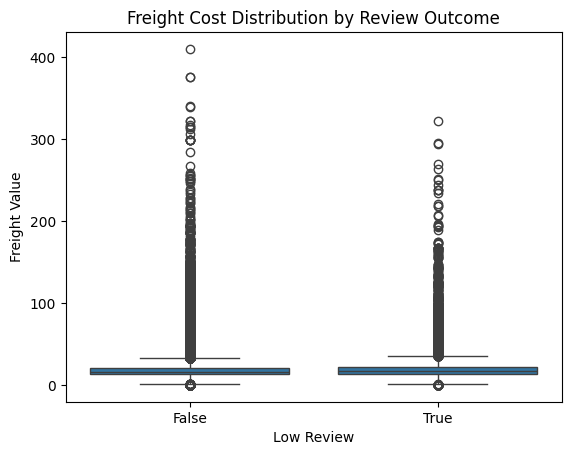

In [26]:
import seaborn as sns
sns.boxplot(x='low_review', y='freight_value', data=olist_df)
plt.title("Freight Cost Distribution by Review Outcome")
plt.xlabel("Low Review")
plt.ylabel("Freight Value")
plt.show()

Though not drastic, lower reviews are associated with higher shipping costs and customers paying more. This potentially reflects customers paying more to higher expectations and being disappointed, however would need more analysis to determine correlation. 

# Final Results and Key Insights
In this project, I explored key drivers of low customer reviews in the Olist e-commerce dataset from Kaggle. I focused on delivery times, product categories, seller behaviors, and pricing factors to see which had the biggest effects. 

**1. Delivery Delays are the strongest drivers for negative customer reviews**
Late deliveries were highly correlated with poor customer satisfaction and therefore, negative reviews. For the orders that arrived late, there was a significantly higher rate of negative reviews compared to the deliveries that arrived on-time or early. This suggest that delivery reliability is one of the most critical factors influencing customer experiences while shopping online. 

**2. Delays were substantial ones compared to a short delay**
Customers that experienced delays faced signifcantly higher delay times on average, reinforcing that not just being late, but being very late has a stronger negative impact on customer reviews. 

**3. Certain product categories consistently underperform**
Results showed that certain product categories like security and services had lower average reviews compared to other categories. This could be an indicator towards their product quality or performing lower than expectations and is a possible opening for future analysis. 
**4. Seller Performance differs by region**
There is some noticeable variation in delivery rates across the different regions that sellers operate out of. Some states show to have consistently higher delivery rates which could suggest that there are inefficiencies or challenges in their operations within these specific regions. 

**5. Price and Shipping Costs are not the main issue**
Though there is a slight increase in the average cost for dissatisfied customers, the difference is too small compared to the impact of delivery delays. This suggests that customers are more sensitive to service quality and product quality than the price. 

**Final Takeaway**
Based on the key factors that I examined throughout this project, delivery performance seems to be the most important factor regarding customer satisfaction in this dataset. This suggests that an improvement in reducing delays and logistics to ensure reliable fulfillment of orders would improve customer satisfaction over pricing nand product quality. However, one important thing to note is multivariate analysis. In this project, I focused on examining individual variables independently. However, customer satisfaction is often influenced by multiple factors and variables may appear insignificant on their own but become important when considered alongside others, and vice versa due to confounding factors. As a next steps, future analysis could involve building predictive models or running regression analysis to look at the relative impact of each factor while controlling for others. This would allow for a more complete understanding of what truly drives customer dissatisfaction. 